# Анализ функций награды для разных алгоритмов

Сравнение Return / Sharpe / Drawdown-наград при обучении DQN и A2C.


In [15]:
import json
import sys
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
sys.path.append(str(project_root / 'src'))

from stable_baselines3 import DQN, A2C
from env import ReturnReward, SharpeReward, DrawdownAwareReward
from agents import DQNConfig, A2CConfig


In [16]:
df_test = pd.read_csv('../data/raw/binance_BTCUSDT_1h_2022.csv')

df_test.head()


,open,high,low,close,volume
0,46216.93,46731.39,46208.37,46656.13,1503.33095
1,46656.14,46949.99,46574.06,46778.14,943.81539
2,46778.14,46928.94,46721.96,46811.77,485.16860
3,46811.77,46916.63,46760.12,46813.20,562.88971
4,46813.21,46887.33,46591.23,46711.05,861.88389


In [17]:
reward_envs = {
    'return': (ReturnReward, {}),
    'sharpe': (SharpeReward, {'eps': 1e-12}),
    'drawdown': (DrawdownAwareReward, {'penalty_lambda': 1.0}),
}

algorithms = {
    'dqn': (DQN, DQNConfig),
    'a2c': (A2C, A2CConfig),
}


In [18]:
def latest_run_dir(base_dir: Path) -> Optional[Path]:
    if not base_dir.exists():
        return None
    runs = [p for p in base_dir.iterdir() if p.is_dir()]
    if not runs:
        return None
    return sorted(runs)[-1]


loaded_runs = []

for algo_name, (AlgoCls, ConfigCls) in algorithms.items():
    for reward_name in reward_envs.keys():
        exp_dir = project_root / 'experiments' / f"{algo_name}-{reward_name}"
        run_dir = latest_run_dir(exp_dir)
        if run_dir is None:
            print(f"Skip: no runs in {exp_dir}")
            continue
        config_path = run_dir / 'config.json'
        model_path = run_dir / 'model.zip'

        config = ConfigCls(**json.loads(config_path.read_text()))

        loaded_runs.append({
            'algo': algo_name,
            'reward': reward_name,
            'model_cls': AlgoCls,
            'model_path': model_path,
            'config': config,
        })


In [19]:
test_steps_all = []

for run in loaded_runs:
    algo = run['algo']
    reward = run['reward']
    model_cls = run['model_cls']
    model_path = run['model_path']

    EnvCls, env_kwargs = reward_envs[reward]
    env_test = EnvCls(df_test, window_size=10, **env_kwargs)
    env_test.clear_history()

    model = model_cls.load(str(model_path), env=env_test)

    obs, _ = env_test.reset()
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward_val, terminated, truncated, info = env_test.step(int(action))
        done = terminated or truncated

    steps = env_test.get_steps_df()
    steps['algo'] = algo
    steps['reward'] = reward
    steps['split'] = 'test'
    test_steps_all.append(steps)


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


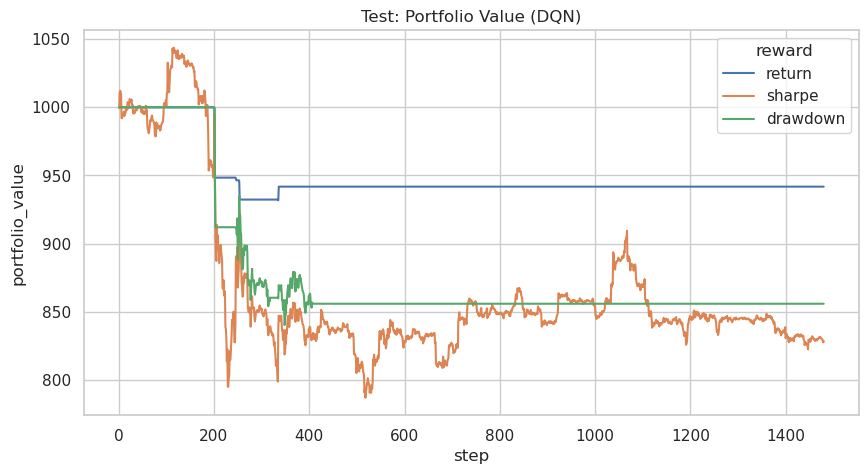

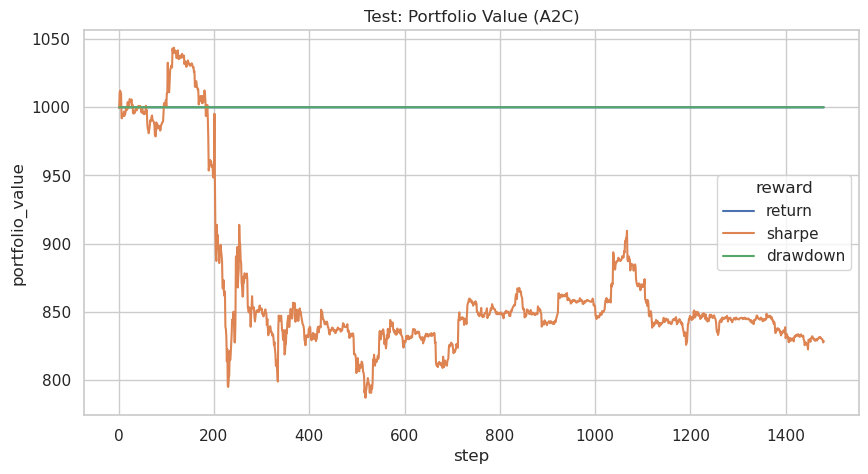

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

test_df = pd.concat(test_steps_all, ignore_index=True)

plt.figure(figsize=(10, 5))
sns.lineplot(data=test_df[test_df['algo'] == 'dqn'], x='step', y='portfolio_value', hue='reward')
plt.title('Test: Portfolio Value (DQN)')
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(data=test_df[test_df['algo'] == 'a2c'], x='step', y='portfolio_value', hue='reward')
plt.title('Test: Portfolio Value (A2C)')
plt.show()


In [21]:
test_df = pd.concat(test_steps_all, ignore_index=True)

summary = (
    test_df.groupby(['algo', 'reward'])
    .agg(final_portfolio=('portfolio_value', 'last'), trades=('n_trades', 'max'))
    .reset_index()
)

summary.sort_values(['algo', 'final_portfolio'], ascending=[True, False])


,algo,reward,final_portfolio,trades
0,a2c,drawdown,1000.000000,0
1,a2c,return,1000.000000,0
2,a2c,sharpe,828.488280,22
4,dqn,return,941.762029,4
3,dqn,drawdown,855.838333,3
5,dqn,sharpe,828.488280,22
